# Misidentification Correction Fits  —  hRatio_p_*

Fits each `hRatio_p_X` histogram as a smooth polynomial in momentum $p$:

$$R(p) = \sum_{k=0}^{d} c_k\, p^k$$

Fit is performed via weighted least squares (WLS) using bin errors as weights,
with a relative-error floor to prevent zero-uncertainty bins dominating.
Analytic fit uncertainty propagates the full coefficient covariance matrix:

$$\sigma_R(p) = \sqrt{\mathbf{f}(p)^\top V \,\mathbf{f}(p)}$$

where $\mathbf{f}(p) = [1, p, p^2, \ldots, p^d]$ and $V$ is the WLS covariance.

**Particles fitted:** π⁺, π⁻, K⁺, K⁻, proton, anti-proton

In [41]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

INPUT_FILE  = '../data/correctionFiles/corrections_misid_mc.root'
OUTPUT_FILE = '../data/correctionFiles/corrections_misid_mc_fit.root'

DEG = 4   # polynomial degree for the ratio fits

REL_SIGMA_FLOOR = 0.02   # minimum relative uncertainty per bin

# Scan range for degree optimisation (cell-scan)
SCAN_DEG = [2, 3, 4, 5, 6]

In [42]:
# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#444444',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        '#dddddd',
    'grid.linewidth':    0.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'font.family':       'sans-serif',
})

# Particle metadata: (hist_key_suffix, display_label, color)
PARTICLES = [
    ('pip',  r'$\pi^+$',       '#e74c3c'),
    ('pim',  r'$\pi^-$',       '#3498db'),
    ('kp',   r'$K^+$',         '#2ecc71'),
    ('km',   r'$K^-$',         '#9b59b6'),
]

In [43]:
# ── Load hRatio_p_* histograms ────────────────────────────────────────────────
f = uproot.open(INPUT_FILE)
print('All keys:', f.keys())
print()

data = {}   # key → {'p_edges', 'p_centers', 'vals', 'errs'}

for suffix, label, _ in PARTICLES:
    hname = f'hFactor_{suffix}'
    h = f[hname]
    edges   = h.axes[0].edges()
    centers = (edges[:-1] + edges[1:]) / 2
    vals    = h.values().copy()
    errs    = h.errors().copy()

    # Mask empty / zero-error bins
    bad = (vals == 0) | (errs == 0) | ~np.isfinite(vals) | ~np.isfinite(errs)
    vals[bad] = np.nan
    errs[bad] = np.nan

    n_valid = int(np.isfinite(vals).sum())
    print(f'{hname}: p=[{edges[0]:.3f}, {edges[-1]:.3f}]  '
          f'nbins={len(vals)}  valid={n_valid}  '
          f'val_range=[{np.nanmin(vals):.4f}, {np.nanmax(vals):.4f}]')

    data[suffix] = dict(
        label    = label,
        p_edges  = edges,
        p_centers= centers,
        vals     = vals,
        errs     = errs,
    )

All keys: ['hRatio_p_pip;1', 'hRatio_theta_p_pip;1', 'hP_eb_pip;1', 'hP_true_pip;1', 'hRatio_p_pim;1', 'hRatio_theta_p_pim;1', 'hP_eb_pim;1', 'hP_true_pim;1', 'hRatio_p_kp;1', 'hRatio_theta_p_kp;1', 'hP_eb_kp;1', 'hP_true_kp;1', 'hRatio_p_km;1', 'hRatio_theta_p_km;1', 'hP_eb_km;1', 'hP_true_km;1', 'hRatio_p_prtp;1', 'hRatio_theta_p_prtp;1', 'hP_eb_prot;1', 'hP_true_prot;1', 'hRatio_p_prtm;1', 'hRatio_theta_p_prtm;1', 'hP_eb_aprot;1', 'hP_true_aprot;1', 'hFactor_pip;1', 'hFactor_pim;1', 'hFactor_kp;1', 'hFactor_km;1', 'hNRICH_p_pip;1', 'hProbRICH_p_pip;1', 'hNRICH_p_eb_pip;1', 'hProbRICH_p_eb_pip;1', 'hNRICH_p_pim;1', 'hProbRICH_p_pim;1', 'hNRICH_p_eb_pim;1', 'hProbRICH_p_eb_pim;1', 'hNRICH_p_kp;1', 'hProbRICH_p_kp;1', 'hNRICH_p_eb_kp;1', 'hProbRICH_p_eb_kp;1', 'hNRICH_p_km;1', 'hProbRICH_p_km;1', 'hNRICH_p_eb_km;1', 'hProbRICH_p_eb_km;1', 'hNRICH_p_prot;1', 'hProbRICH_p_prot;1', 'hNRICH_p_eb_prot;1', 'hProbRICH_p_eb_prot;1', 'hNRICH_p_aprot;1', 'hProbRICH_p_aprot;1', 'hNRICH_p_eb_aprot

In [44]:
# ── WLS polynomial fit ────────────────────────────────────────────────────────

def wls(X, y, w):
    """Weighted least-squares via SVD.

    Returns
    -------
    coeffs  : (n_params,)             fitted coefficients
    sigmas  : (n_params,)             per-coefficient 1-sigma uncertainties
    cov     : (n_params, n_params)    full covariance matrix
    """
    Xw = X * w[:, None]
    U, s, Vt = np.linalg.svd(Xw, full_matrices=False)
    thresh = 1e-12 * s[0] if s[0] > 0 else 1e-12
    sinv   = np.where(s > thresh, 1.0 / s, 0.0)
    coeffs = (Vt.T * sinv) @ (U.T @ (y * w))
    cov    = (Vt.T * sinv**2) @ Vt
    sigmas = np.sqrt(np.maximum(np.diag(cov), 0))
    return coeffs, sigmas, cov


def poly_features(p, deg):
    """Vandermonde matrix: columns are p^0, p^1, ..., p^deg."""
    return np.column_stack([p ** k for k in range(deg + 1)])


def fit_ratio(vals, errs, p_centers, label='', deg=None):
    """
    Fit R(p) = Σ_k c_k p^k  using WLS on valid (non-NaN) bins.

    Returns
    -------
    coeffs, cov, predict

    predict(p)         → R(p)
    predict.sigma(p)   → 1-sigma uncertainty on R(p)
    predict.cov        → coefficient covariance matrix
    """
    if deg is None:
        deg = DEG

    mask = np.isfinite(vals) & np.isfinite(errs)
    p_v, y_v, e_v = p_centers[mask], vals[mask], errs[mask]
    n_valid = len(y_v)

    if n_valid < deg + 1:
        raise ValueError(f'{label}: only {n_valid} valid bins for degree-{deg} fit.')

    # Normalise p to [-1, 1] for numerical stability
    p_lo, p_hi = p_v.min(), p_v.max()
    p_scale    = (p_lo + p_hi) / 2
    p_range    = (p_hi - p_lo) / 2 if p_hi > p_lo else 1.0
    p_norm     = (p_v - p_scale) / p_range

    X   = poly_features(p_norm, deg)
    w   = 1.0 / np.maximum(e_v, np.abs(y_v) * REL_SIGMA_FLOOR)

    coeffs, sigmas, cov = wls(X, y_v, w)

    ndof  = n_valid - (deg + 1)
    resid = y_v - X @ coeffs
    chi2  = float(np.sum((resid * w) ** 2))
    chi2_ndof = chi2 / ndof if ndof > 0 else np.nan
    print(f'  {label:12s} deg={deg}  n_bins={n_valid}  ndof={ndof}  '
          f'χ²/ndof={chi2_ndof:.4f}')

    _c, _cov = coeffs, cov

    def predict(p_in):
        p_in  = np.asarray(p_in)
        p_n   = (p_in - p_scale) / p_range
        feat  = poly_features(p_n, deg)
        return feat @ _c

    def predict_sigma(p_in):
        p_in  = np.asarray(p_in)
        p_n   = (p_in - p_scale) / p_range
        feat  = poly_features(p_n, deg)
        var   = np.einsum('ni,ij,nj->n', feat, _cov, feat)
        return np.sqrt(np.maximum(var, 0))

    predict.sigma      = predict_sigma
    predict.cov        = cov
    predict.coeffs     = coeffs
    predict.p_scale    = p_scale
    predict.p_range    = p_range
    predict.deg        = deg
    predict.chi2_ndof  = chi2_ndof
    predict.n_valid    = n_valid

    return coeffs, cov, predict


# ── Run fits ──────────────────────────────────────────────────────────────────
print(f'Polynomial degree: {DEG}')
fits = {}   # suffix → predict

for suffix, label, _ in PARTICLES:
    d = data[suffix]
    try:
        _, _, pred = fit_ratio(d['vals'], d['errs'], d['p_centers'],
                               label=label, deg=DEG)
        fits[suffix] = pred
    except ValueError as exc:
        print(f'  SKIP {label}: {exc}')
        fits[suffix] = None

Polynomial degree: 4
  $\pi^+$      deg=4  n_bins=20  ndof=15  χ²/ndof=0.0301
  $\pi^-$      deg=4  n_bins=20  ndof=15  χ²/ndof=0.1110
  $K^+$        deg=4  n_bins=20  ndof=15  χ²/ndof=2.6603
  $K^-$        deg=4  n_bins=20  ndof=15  χ²/ndof=0.8342


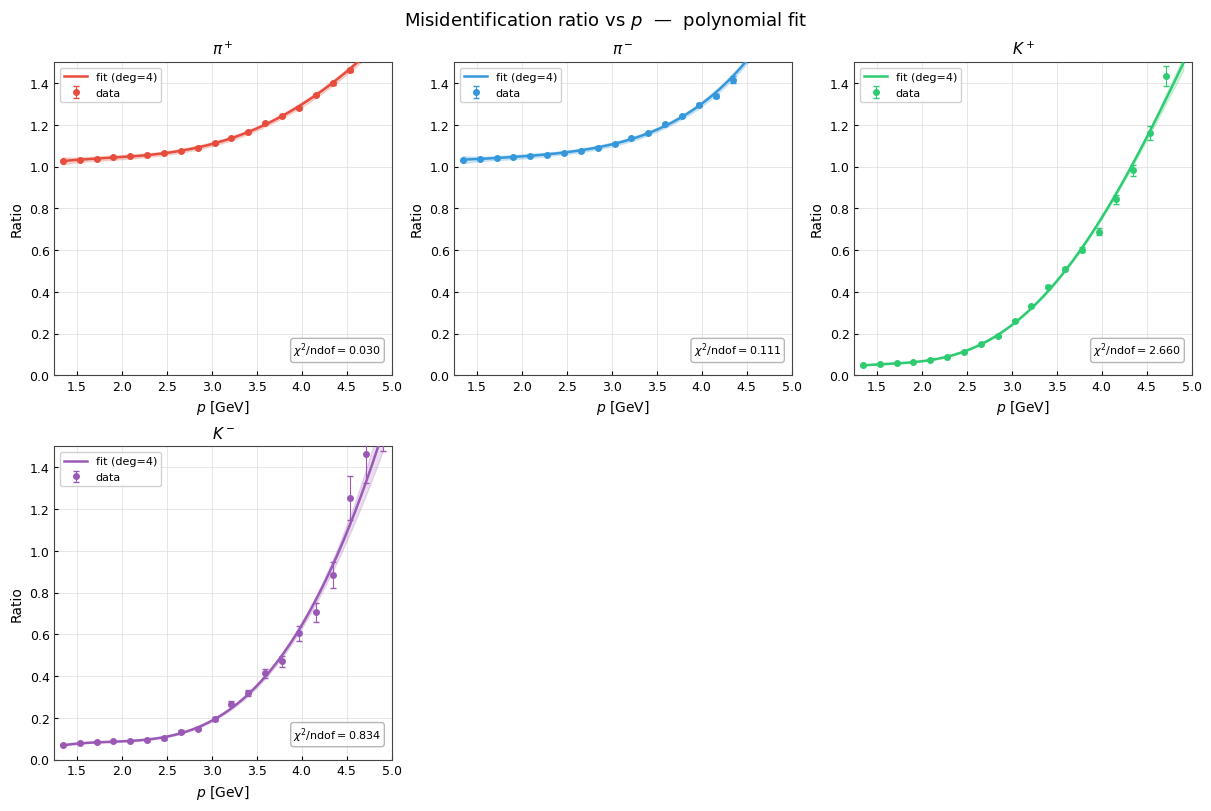

In [45]:
# ── Plot: all particles on one figure ─────────────────────────────────────────
n_part = len(PARTICLES)
ncols  = 3
nrows  = -(-n_part // ncols)   # ceiling division

fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows),
                         constrained_layout=True, squeeze=False)
fig.suptitle('Misidentification ratio vs $p$  —  polynomial fit', fontsize=13)

p_fine_global = np.linspace(1.25, 5.0, 500)

for idx, (suffix, label, color) in enumerate(PARTICLES):
    row, col = divmod(idx, ncols)
    ax  = axs[row, col]
    d   = data[suffix]
    pred = fits.get(suffix)

    pc, vals, errs = d['p_centers'], d['vals'], d['errs']
    edges = d['p_edges']

    # ── Data points ───────────────────────────────────────────────────────────
    mask = np.isfinite(vals)
    ax.errorbar(pc[mask], vals[mask], yerr=errs[mask],
                fmt='o', color=color, ms=4, lw=0.8, capsize=2,
                label='data', zorder=3)

    # ── Fit curve + uncertainty band ──────────────────────────────────────────
    if pred is not None:
        # Restrict fine grid to the valid momentum range
        p_lo = pc[mask].min() if mask.any() else edges[0]
        p_hi = pc[mask].max() if mask.any() else edges[-1]
        p_fine = np.linspace(p_lo, p_hi, 500)

        r_fit  = pred(p_fine)
        r_sig  = pred.sigma(p_fine)

        ax.plot(p_fine, r_fit, color=color, lw=1.8,
                label=f'fit (deg={pred.deg})', zorder=4)
        ax.fill_between(p_fine, r_fit - r_sig, r_fit + r_sig,
                        color=color, alpha=0.20, zorder=2)

        # χ²/ndof annotation
        ax.text(0.97, 0.05,
                rf'$\chi^2/\mathrm{{ndof}}={pred.chi2_ndof:.3f}$',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.25', fc='white',
                          ec='#aaaaaa', alpha=0.85))

    ax.set_title(label, fontsize=11)
    ax.set_xlabel(r'$p$ [GeV]', fontsize=10)
    ax.set_ylabel('Ratio', fontsize=10)
    ax.set_xlim(edges[0], edges[-1])
    ax.set_ylim(0, 1.5)
    ax.legend(fontsize=8)

for idx in range(n_part, nrows * ncols):
    axs.ravel()[idx].set_visible(False)

plt.show()

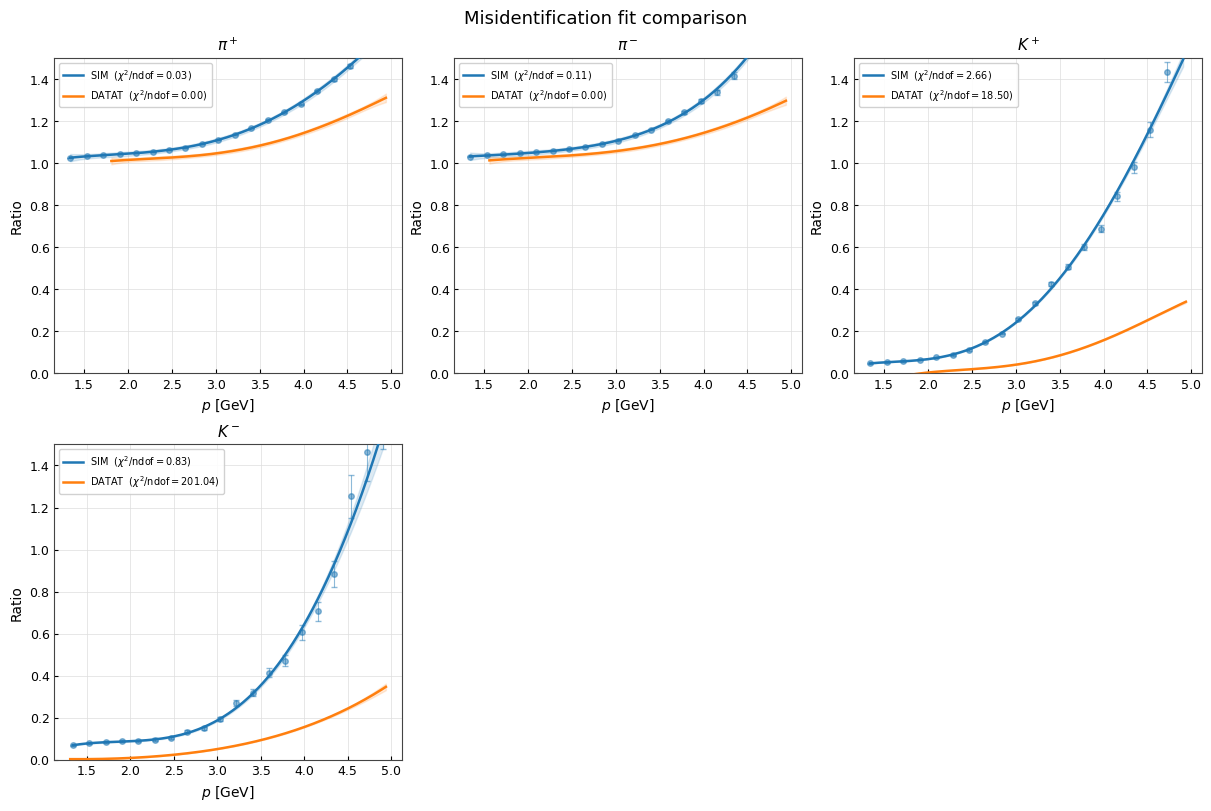

In [ ]:
# ── Compare fits from multiple files ──────────────────────────────────────────
# Add entries to COMPARE_FILES to overlay fits from different correction files.
COMPARE_FILES = [
    (INPUT_FILE, 'SIM'),
    ('../data/correctionFiles/corrections_misid_AN.root', 'DATA'),
]

import io, contextlib

def _load_and_fit_file(filepath, deg=DEG):
    """Load hFactor_* histograms from filepath and fit each particle."""
    out = {}
    with uproot.open(filepath) as f_in:
        for suffix, label, _ in PARTICLES:
            hname = f'hFactor_{suffix}'
            if hname not in f_in and (hname + ';1') not in f_in:
                continue
            h       = f_in[hname]
            edges   = h.axes[0].edges()
            centers = (edges[:-1] + edges[1:]) / 2
            vals    = h.values().copy()
            errs    = h.errors().copy()
            bad = (vals == 0) | (errs == 0) | ~np.isfinite(vals) | ~np.isfinite(errs)
            vals[bad] = np.nan;  errs[bad] = np.nan
            try:
                with contextlib.redirect_stdout(io.StringIO()):
                    _, _, pred = fit_ratio(vals, errs, centers, label=label, deg=deg)
            except ValueError:
                pred = None
            out[suffix] = dict(p_edges=edges, p_centers=centers,
                               vals=vals, errs=errs, pred=pred)
    return out

cmap_cmp   = plt.get_cmap('tab10')
file_colors = [cmap_cmp(i) for i in range(len(COMPARE_FILES))]

all_datasets = [(lbl, _load_and_fit_file(fp)) for fp, lbl in COMPARE_FILES]

ncols = 3
nrows = -(-len(PARTICLES) // ncols)
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows),
                         constrained_layout=True, squeeze=False)
fig.suptitle('Misidentification fit comparison', fontsize=13)

for idx, (suffix, part_label, _) in enumerate(PARTICLES):
    row, col = divmod(idx, ncols)
    ax = axs[row, col]
    ax.set_title(part_label, fontsize=11)
    ax.set_xlabel(r'$p$ [GeV]', fontsize=10)
    ax.set_ylabel('Ratio', fontsize=10)

    for fi, (file_label, ds) in enumerate(all_datasets):
        d = ds.get(suffix)
        if d is None:
            continue
        pc, vals, errs = d['p_centers'], d['vals'], d['errs']
        pred  = d['pred']
        mask  = np.isfinite(vals)
        col_c = file_colors[fi]

        if fi == 0 and mask.any():
            ax.errorbar(pc[mask], vals[mask], yerr=errs[mask],
                        fmt='o', color=col_c, ms=4, lw=0.8, capsize=2,
                        alpha=0.5, zorder=2)

        if pred is not None:
            p_lo   = pc[mask].min() if mask.any() else d['p_edges'][0]
            p_hi   = pc[mask].max() if mask.any() else d['p_edges'][-1]
            p_fine = np.linspace(p_lo, p_hi, 500)
            r_fit  = pred(p_fine)
            r_sig  = pred.sigma(p_fine)
            ax.plot(p_fine, r_fit, color=col_c, lw=1.8, zorder=4,
                    label=rf'{file_label}  ($\chi^2/\mathrm{{ndof}}={pred.chi2_ndof:.2f}$)')
            ax.fill_between(p_fine, r_fit - r_sig, r_fit + r_sig,
                            color=col_c, alpha=0.15, zorder=3)

    ax.set_ylim(0, 1.5)
    ax.legend(fontsize=7)

for idx in range(len(PARTICLES), nrows * ncols):
    axs.ravel()[idx].set_visible(False)

plt.show()

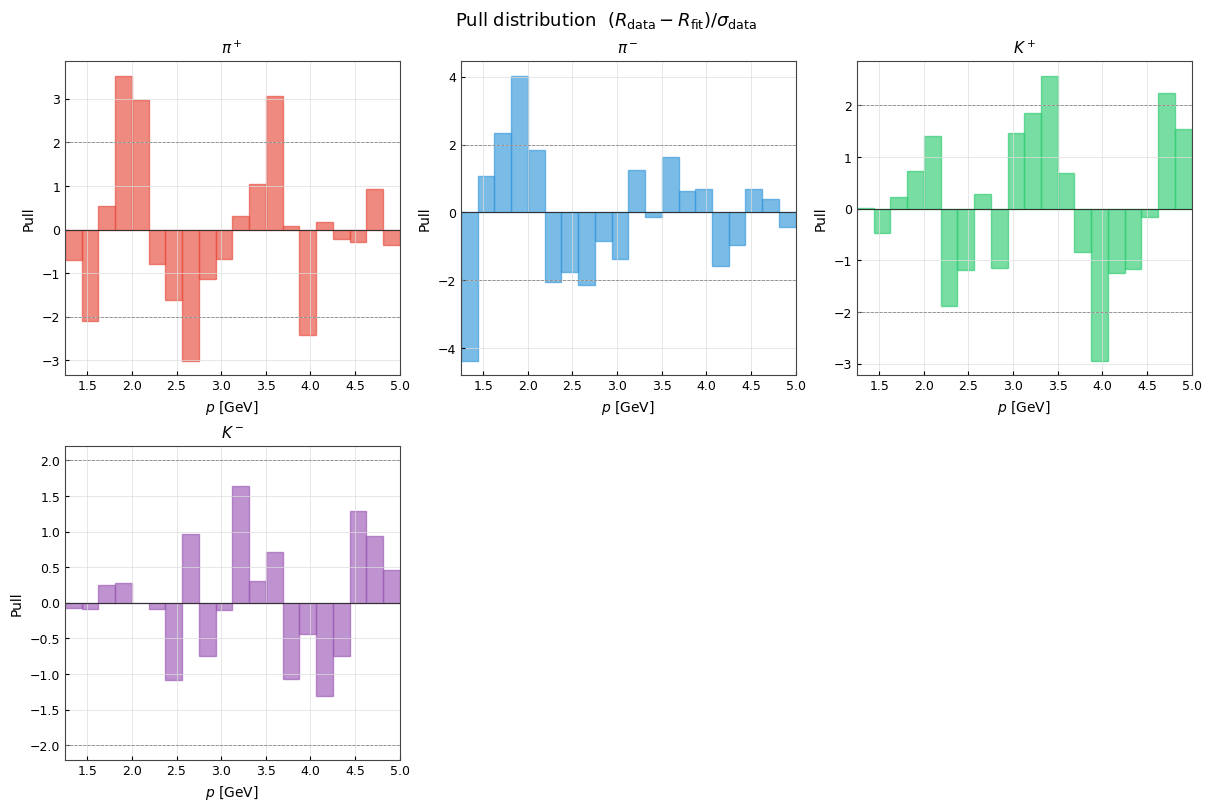

In [47]:
# ── Residual plot: (data − fit) / σ_data ──────────────────────────────────────
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows),
                         constrained_layout=True, squeeze=False)
fig.suptitle('Pull distribution  $(R_{\\mathrm{data}} - R_{\\mathrm{fit}}) / \\sigma_{\\mathrm{data}}$',
             fontsize=13)

for idx, (suffix, label, color) in enumerate(PARTICLES):
    row, col = divmod(idx, ncols)
    ax   = axs[row, col]
    d    = data[suffix]
    pred = fits.get(suffix)

    pc, vals, errs = d['p_centers'], d['vals'], d['errs']
    mask = np.isfinite(vals)

    if pred is not None and mask.any():
        r_fit = pred(pc[mask])
        pull  = (vals[mask] - r_fit) / errs[mask]
        ax.bar(pc[mask], pull,
               width=np.diff(d['p_edges'])[mask],
               color=color, alpha=0.65, edgecolor=color)
        ax.axhline(0,  color='#333333', lw=0.8)
        ax.axhline(+2, color='#888888', lw=0.6, ls='--')
        ax.axhline(-2, color='#888888', lw=0.6, ls='--')

    ax.set_title(label, fontsize=11)
    ax.set_xlabel(r'$p$ [GeV]', fontsize=10)
    ax.set_ylabel('Pull', fontsize=10)
    ax.set_xlim(d['p_edges'][0], d['p_edges'][-1])

for idx in range(n_part, nrows * ncols):
    axs.ravel()[idx].set_visible(False)

plt.show()

Scanning degrees: [2, 3, 4, 5, 6]

$\pi^+$ :  deg=2: 0.2770  deg=3: 0.0401  deg=4: 0.0301 ←best  deg=5: 0.0322  deg=6: 0.0315
$\pi^-$ :  deg=2: 1.0624  deg=3: 0.1265  deg=4: 0.1110 ←best  deg=5: 0.1176  deg=6: 0.1181
$K^+$   :  deg=2: 23.9860  deg=3: 4.5558  deg=4: 2.6603  deg=5: 2.2351  deg=6: 1.2547 ←best
$K^-$   :  deg=2: 10.2743  deg=3: 0.8096  deg=4: 0.8342  deg=5: 0.7445  deg=6: 0.6463 ←best


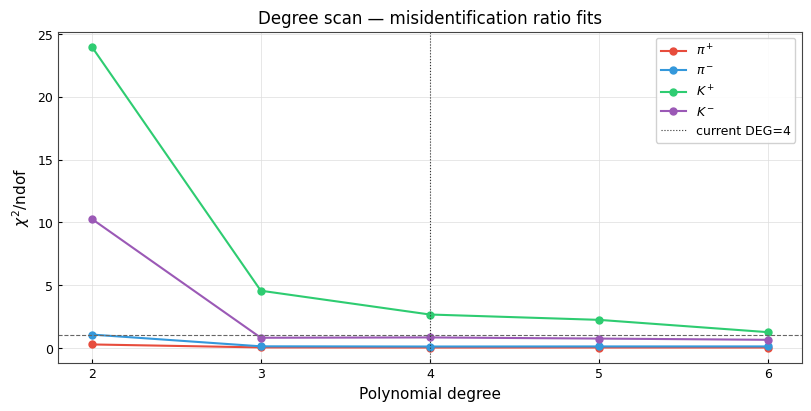

In [48]:
# ── Degree scan: χ²/ndof vs polynomial degree for each particle ───────────────
import io, contextlib

scan_results = {}   # (suffix, deg) → chi2_ndof

print(f'Scanning degrees: {SCAN_DEG}\n')
for suffix, label, _ in PARTICLES:
    d = data[suffix]
    for deg in SCAN_DEG:
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                _, _, pred = fit_ratio(d['vals'], d['errs'], d['p_centers'],
                                       label=label, deg=deg)
            scan_results[(suffix, deg)] = pred.chi2_ndof
        except Exception:
            scan_results[(suffix, deg)] = np.nan
    best_deg = min(SCAN_DEG,
                   key=lambda dg: scan_results[(suffix, dg)]
                   if np.isfinite(scan_results[(suffix, dg)]) else np.inf)
    print(f'{label:8s}:', end='')
    for deg in SCAN_DEG:
        v = scan_results[(suffix, deg)]
        marker = ' ←best' if deg == best_deg else ''
        print(f'  deg={deg}: {v:.4f}{marker}', end='')
    print()

# ── Plot scan ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for suffix, label, color in PARTICLES:
    vals_scan = [scan_results[(suffix, dg)] for dg in SCAN_DEG]
    ax.plot(SCAN_DEG, vals_scan, 'o-', color=color, lw=1.5, ms=5, label=label)

ax.axhline(1.0, color='#666666', lw=0.8, ls='--')
ax.axvline(DEG, color='#333333', lw=0.8, ls=':', label=f'current DEG={DEG}')
ax.set_xlabel('Polynomial degree', fontsize=11)
ax.set_ylabel(r'$\chi^2/\mathrm{ndof}$', fontsize=11)
ax.set_title('Degree scan — misidentification ratio fits', fontsize=12)
ax.legend(fontsize=9)
ax.set_xticks(SCAN_DEG)
plt.show()

In [49]:
# ── Write fit results to ROOT file ────────────────────────────────────────────
#
# Written objects (all TH1F, axis = p):
#
#   hRatio_p_<X>           original ratio histogram (pass-through)
#   hRatio_p_<X>_fit       fit R(p) evaluated at each bin centre
#   hRatio_p_<X>_fit_sigma analytic 1-sigma uncertainty on the fit
#   hRatio_p_<X>_ratio     data / fit  (≈1 where fit is good)

import boost_histogram as bh


def _make_bh1(edges, values, variances):
    """Build a boost_histogram TH1F from (n_bins,) arrays."""
    h = bh.Histogram(
        bh.axis.Variable(edges),
        storage=bh.storage.Weight(),
    )
    h.view().value    = np.nan_to_num(values,   nan=0.0)
    h.view().variance = np.nan_to_num(variances, nan=0.0)
    return h


def write_fit_histograms(output_path):
    print(f'Writing fit histograms to {output_path} ...')
    written = []
    with uproot.recreate(output_path) as fout:
        for suffix, label, _ in PARTICLES:
            d    = data[suffix]
            pred = fits.get(suffix)
            edges  = d['p_edges']
            pc     = d['p_centers']
            vals_d = d['vals']
            errs_d = d['errs']

            # Original histogram
            fout[f'hRatio_p_{suffix}'] = _make_bh1(
                edges, vals_d, errs_d**2)
            written.append(f'hRatio_p_{suffix}')

            if pred is None:
                continue

            # Fit values at bin centres
            r_fit  = pred(pc)
            r_sig  = pred.sigma(pc)

            fout[f'hRatio_p_{suffix}_fit'] = _make_bh1(
                edges, r_fit, r_sig**2)
            fout[f'hRatio_p_{suffix}_fit_sigma'] = _make_bh1(
                edges, r_sig, np.zeros_like(r_sig))
            written.append(f'hRatio_p_{suffix}_fit')
            written.append(f'hRatio_p_{suffix}_fit_sigma')

            # data / fit ratio
            with np.errstate(invalid='ignore', divide='ignore'):
                ratio = np.where(
                    np.isfinite(vals_d) & (r_fit > 0),
                    vals_d / r_fit, np.nan)
                ratio_err = np.where(
                    np.isfinite(ratio),
                    ratio * (errs_d / vals_d), np.nan)

            fout[f'hRatio_p_{suffix}_ratio'] = _make_bh1(
                edges, ratio, ratio_err**2)
            written.append(f'hRatio_p_{suffix}_ratio')

    print('Done.  Histograms written:')
    for name in written:
        print(f'  {name}')


write_fit_histograms(OUTPUT_FILE)

Writing fit histograms to ../data/correctionFiles/corrections_misid_mc_fit.root ...
Done.  Histograms written:
  hRatio_p_pip
  hRatio_p_pip_fit
  hRatio_p_pip_fit_sigma
  hRatio_p_pip_ratio
  hRatio_p_pim
  hRatio_p_pim_fit
  hRatio_p_pim_fit_sigma
  hRatio_p_pim_ratio
  hRatio_p_kp
  hRatio_p_kp_fit
  hRatio_p_kp_fit_sigma
  hRatio_p_kp_ratio
  hRatio_p_km
  hRatio_p_km_fit
  hRatio_p_km_fit_sigma
  hRatio_p_km_ratio


In [50]:
# ── Write TF1 fit functions to ROOT file (requires PyROOT) ────────────────────
#
# Appends TF1 objects to OUTPUT_FILE (UPDATE mode).
#
#   hRatio_p_<X>_tf1        R(p) as a continuous TF1
#   hRatio_p_<X>_tf1_sigma  σ_R(p) as a continuous TF1
#
# TF1 variable: x = p (momentum in GeV)
#
# Usage in C++:
#   TF1 *rP  = (TF1*) f->Get("hRatio_p_pip_tf1");
#   double ratio = rP->Eval(p);


def _build_tf1_formula(coeffs, p_scale, p_range, deg):
    """
    R(p) = Σ_k c_k * ((p - p_scale)/p_range)^k
    Expand in terms of the normalised variable to keep numerical precision.
    """
    pn = f'((x-{p_scale:.15e})/{p_range:.15e})'
    terms = []
    for k, c in enumerate(coeffs):
        if c == 0.0:
            continue
        if k == 0:
            terms.append(f'({c:.15e})')
        elif k == 1:
            terms.append(f'({c:.15e})*{pn}')
        elif k == 2:
            terms.append(f'({c:.15e})*{pn}*{pn}')
        else:
            terms.append(f'({c:.15e})*pow({pn},{k})')
    return '+'.join(terms) if terms else '0'


def _build_tf1_sigma_formula(coeffs, cov, p_scale, p_range, deg):
    """
    σ_R(p) = sqrt( f(p)ᵀ V f(p) )

    numpy cholesky gives lower-triangular L with V = LLᵀ, so:

        fᵀVf = ||Lᵀf||² = Σ_k (Σ_i L[i,k] f_i)²   ← column k of L

    L is lower triangular so L[i,k] = 0 for i < k.
    """
    n   = len(coeffs)
    pn  = f'((x-{p_scale:.15e})/{p_range:.15e})'

    def feat_str(k):
        if k == 0: return '1'
        if k == 1: return pn
        if k == 2: return f'{pn}*{pn}'
        return f'pow({pn},{k})'

    feat_strs = [feat_str(k) for k in range(n)]

    try:
        L = np.linalg.cholesky(cov + np.eye(n) * 1e-14 * np.trace(cov) / n)
        # Column k of L: L[i,k] for i = k..n-1  (lower triangular → zero for i<k)
        sq_terms = []
        for k in range(n):
            col_terms = [f'({L[i,k]:.15e})*{feat_strs[i]}'
                         if feat_strs[i] != '1' else f'({L[i,k]:.15e})'
                         for i in range(k, n) if L[i, k] != 0.0]
            if not col_terms:
                continue
            inner = '+'.join(col_terms)
            sq_terms.append(f'({inner})*({inner})')
        var_str = '+'.join(sq_terms) if sq_terms else '0'
    except np.linalg.LinAlgError:
        cross = []
        for i in range(n):
            for j in range(n):
                v = cov[i, j]
                if v == 0.0:
                    continue
                cross.append(f'({v:.15e})*{feat_strs[i]}*{feat_strs[j]}')
        var_str = '+'.join(cross) if cross else '0'

    return f'sqrt(abs({var_str}))'


def write_tf1(output_path):
    try:
        import ROOT
        ROOT.gROOT.SetBatch(True)
    except ImportError:
        print('PyROOT not available — printing formula strings instead.')
        for suffix, label, _ in PARTICLES:
            pred = fits.get(suffix)
            if pred is None:
                continue
            fml   = _build_tf1_formula(
                pred.coeffs, pred.p_scale, pred.p_range, pred.deg)
            sfml  = _build_tf1_sigma_formula(
                pred.coeffs, pred.cov, pred.p_scale, pred.p_range, pred.deg)
            print(f'\n{label}  R(p):    {fml[:120]}...')
            print(f'{label}  σ_R(p): {sfml[:120]}...')
        return

    froot = ROOT.TFile.Open(output_path, 'UPDATE')
    written = []

    for suffix, label, _ in PARTICLES:
        pred = fits.get(suffix)
        if pred is None:
            continue

        d     = data[suffix]
        edges = d['p_edges']
        xlo, xhi = float(edges[0]), float(edges[-1])

        fml  = _build_tf1_formula(
            pred.coeffs, pred.p_scale, pred.p_range, pred.deg)
        sfml = _build_tf1_sigma_formula(
            pred.coeffs, pred.cov, pred.p_scale, pred.p_range, pred.deg)

        tf1   = ROOT.TF1(f'hRatio_p_{suffix}_tf1',       fml,  xlo, xhi)
        tf1_s = ROOT.TF1(f'hRatio_p_{suffix}_tf1_sigma', sfml, xlo, xhi)

        lbl_root = label.replace('$', '').replace('\\', '').replace('^', '^{')
        tf1  .SetTitle(f'Ratio {lbl_root};p [GeV];R')
        tf1_s.SetTitle(f'#sigma_{{R}} {lbl_root};p [GeV];#sigma_{{R}}')

        tf1  .Write('', ROOT.TObject.kOverwrite)
        tf1_s.Write('', ROOT.TObject.kOverwrite)
        written += [f'hRatio_p_{suffix}_tf1', f'hRatio_p_{suffix}_tf1_sigma']

    froot.Close()

    print(f'TF1 objects written to {output_path}:')
    for name in written:
        print(f'  {name}')
    print('\nUsage in C++:')
    print('  TF1 *rP  = (TF1*) f->Get("hRatio_p_pip_tf1");')
    print('  double ratio = rP->Eval(p);')


write_tf1(OUTPUT_FILE)

TF1 objects written to ../data/correctionFiles/corrections_misid_mc_fit.root:
  hRatio_p_pip_tf1
  hRatio_p_pip_tf1_sigma
  hRatio_p_pim_tf1
  hRatio_p_pim_tf1_sigma
  hRatio_p_kp_tf1
  hRatio_p_kp_tf1_sigma
  hRatio_p_km_tf1
  hRatio_p_km_tf1_sigma

Usage in C++:
  TF1 *rP  = (TF1*) f->Get("hRatio_p_pip_tf1");
  double ratio = rP->Eval(p);
